# Timbre Metrics Demo

This notebook demonstrates how to use `TimbreMetrics` from `src/evaluation/timbre_metrics.py` to extract timbre descriptors from a frame-based spectral time history.

It includes:
- synthetic test signals
- per-frame feature series from spectral time history
- frame-wise feature extraction aggregated to one row per signal
- optional extraction from a real `.wav` file in `data/`

In [2]:
from pathlib import Path
import sys

import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "evaluation" / "timbre_metrics.py").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing src/evaluation/timbre_metrics.py")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from evaluation.timbre_metrics import TimbreMetrics
from visualize import plot_series,plot_feature_from_audio

print(f"Project root: {PROJECT_ROOT}")

2026-03-19 23:12:07.461280: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-19 23:12:07.751293: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-19 23:12:08.929481: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-11.8/lib64:/usr/local/cuda-11.2/lib64:
2026-03-19 23:12:08.929653: W tensorflow/co

2026-03-19 23:12:07.461280: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-19 23:12:07.751293: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-19 23:12:08.929481: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-11.8/lib64:/usr/local/cuda-11.2/lib64:
2026-03-19 23:12:08.929653: W tensorflow/co

Project root: /home/namkhanh/Project/final_project


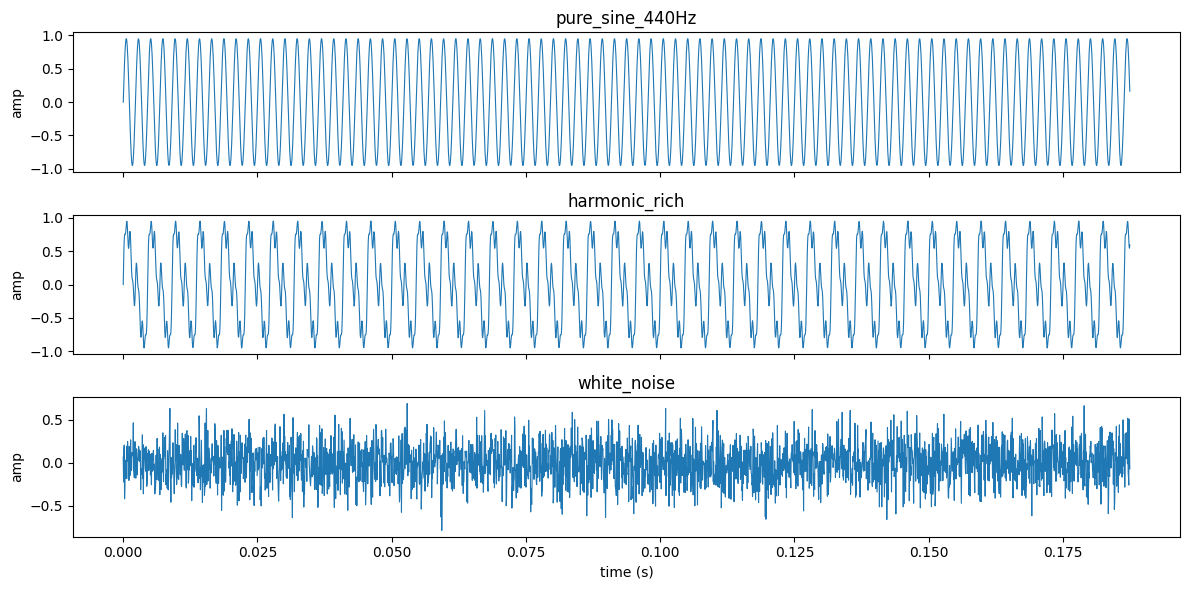

Audio previews:
pure_sine_440Hz


harmonic_rich


white_noise


In [3]:
sr = 16000
duration = 2.0
t = np.linspace(0.0, duration, int(sr * duration), endpoint=False)

def normalize(x: np.ndarray, peak: float = 0.95) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    m = np.max(np.abs(x))
    if m == 0.0:
        return x
    return peak * (x / m)

signals = {
    "pure_sine_440Hz": normalize(np.sin(2 * np.pi * 440.0 * t)),
    "harmonic_rich": normalize(
        np.sin(2 * np.pi * 220.0 * t)
        + 0.6 * np.sin(2 * np.pi * 440.0 * t)
        + 0.3 * np.sin(2 * np.pi * 880.0 * t)
        + 0.2 * np.sin(2 * np.pi * 1760.0 * t)
    ),
    "white_noise": normalize(np.random.default_rng(42).standard_normal(len(t))),
}

fig, axes = plt.subplots(len(signals), 1, figsize=(12, 6), sharex=True)
if len(signals) == 1:
    axes = [axes]

for ax, (name, x) in zip(axes, signals.items()):
    ax.plot(t[:3000], x[:3000], linewidth=0.8)
    ax.set_title(name)
    ax.set_ylabel("amp")

axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

print("Audio previews:")
for name, x in signals.items():
    print(name)
    display(ipd.Audio(x, rate=sr))

In [4]:
extractor = TimbreMetrics(sample_rate=sr, frame_width_sec=0.25, overlap_pct=0.5)
print(f"Extractor config: frame_width_sec={extractor.frame_width_sec}, overlap_pct={extractor.overlap_pct}")

series_rows = {}
for name, x in signals.items():
    series_rows[name] = extractor.extract_series_from_array(x)

for name, series_dict in series_rows.items():
    print(f"{name}: {len(series_dict)} frame-wise features")
    if not series_dict:
        continue
    sample_keys = sorted(series_dict.keys())
    print("  sample keys:", sample_keys)
    first_key = sample_keys[0]
    print(f"  {first_key} shape: {series_dict[first_key].shape}")

Extractor config: frame_width_sec=0.25, overlap_pct=0.5
pure_sine_440Hz: 11 frame-wise features
  sample keys: ['mean_center', 'spectral_centroid', 'spectral_crest', 'spectral_decrease', 'spectral_energy', 'spectral_flatness', 'spectral_kurtosis', 'spectral_roll_off', 'spectral_skewness', 'spectral_slope', 'spectral_spread']
  mean_center shape: (15,)
harmonic_rich: 11 frame-wise features
  sample keys: ['mean_center', 'spectral_centroid', 'spectral_crest', 'spectral_decrease', 'spectral_energy', 'spectral_flatness', 'spectral_kurtosis', 'spectral_roll_off', 'spectral_skewness', 'spectral_slope', 'spectral_spread']
  mean_center shape: (15,)
white_noise: 11 frame-wise features
  sample keys: ['mean_center', 'spectral_centroid', 'spectral_crest', 'spectral_decrease', 'spectral_energy', 'spectral_flatness', 'spectral_kurtosis', 'spectral_roll_off', 'spectral_skewness', 'spectral_slope', 'spectral_spread']
  mean_center shape: (15,)


spec_la not found. Trying another available feature.


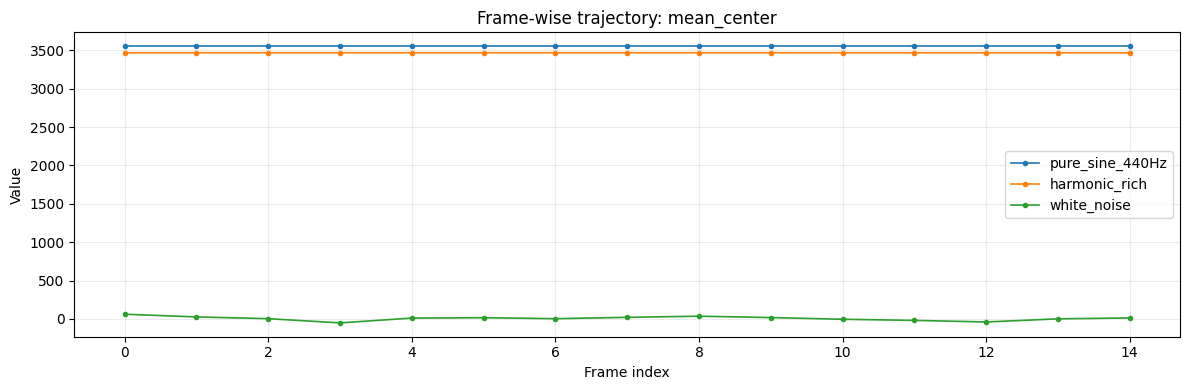

In [5]:
feature_to_plot = "spec_la" if "spec_la" in next(iter(series_rows.values())).keys() else None

if feature_to_plot is None:
    print("spec_la not found. Trying another available feature.")
    first_non_empty = next((v for v in series_rows.values() if v), {})
    if first_non_empty:
        feature_to_plot = sorted(first_non_empty.keys())[0]

if feature_to_plot is None:
    print("No frame-wise features available to plot.")
else:
    plt.figure(figsize=(12, 4))
    for name, series_dict in series_rows.items():
        if feature_to_plot not in series_dict:
            continue
        y = series_dict[feature_to_plot]
        x = np.arange(len(y))
        plt.plot(x, y, marker='o', markersize=3, linewidth=1.2, label=name)

    plt.title(f"Frame-wise trajectory: {feature_to_plot}")
    plt.xlabel("Frame index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [6]:
extractor = TimbreMetrics(sample_rate=sr, frame_width_sec=0.25, overlap_pct=0)
print(f"Extractor config: frame_width_sec={extractor.frame_width_sec}, overlap_pct={extractor.overlap_pct}")

def to_numeric(v):
    if isinstance(v, (int, float, np.integer, np.floating)):
        return float(v)
    return np.nan

feature_rows = {}
for name, x in signals.items():
    feats = extractor.extract_from_array(x)

    feature_rows[name] = {k: to_numeric(v) for k, v in feats.items()}

feature_df = pd.DataFrame.from_dict(feature_rows, orient="index")
feature_df = feature_df.reindex(sorted(feature_df.columns), axis=1)

print(f"Extracted features for {len(feature_df)} signals")
print(f"Total metric columns: {feature_df.shape[1]}")

display(feature_df.iloc[:, : min(12, feature_df.shape[1])].round(4))

Extractor config: frame_width_sec=0.25, overlap_pct=0
Extracted features for 3 signals
Total metric columns: 11


,mean_center,spectral_centroid,spectral_crest,spectral_decrease,spectral_energy,spectral_flatness,spectral_kurtosis,spectral_roll_off,spectral_skewness,spectral_slope,spectral_spread
pure_sine_440Hz,3556.2340,439.8598,454.6186,0.0178,0.4513,0.0000,15505.5104,453.1250,44.7187,-0.0,10.5524
harmonic_rich,3469.8458,526.2479,229.7034,0.0236,0.3449,0.0000,5.1633,1757.8125,1.7880,-0.0,458.6483
white_noise,9.4279,3986.6659,2.2857,0.0006,0.0475,0.9306,1.8074,7603.5156,0.0156,-0.0,2307.0365


In [7]:
preferred_cols = [
    # "spectral_centroid",
    # "spectral_spread",
    "spectral_flatness",
    # "spectral_roll_off",
    # "spectral_crest",
    "spectral_skewness",
    "spectral_decrease",
    "spectral_flux",
]

available = [c for c in preferred_cols if c in feature_df.columns]
if available:
    print("Commonly useful aggregated time-history descriptors:")
    display(feature_df[available].round(4))
else:
    print("Preferred columns not found. Showing top varying numeric features instead.")
    variances = feature_df.var(axis=0, numeric_only=True).sort_values(ascending=False)
    top_cols = variances.index.tolist()
    display(feature_df[top_cols].round(4))

Commonly useful aggregated time-history descriptors:


Commonly useful aggregated time-history descriptors:


,spectral_flatness,spectral_skewness,spectral_decrease
pure_sine_440Hz,0.0000,44.7187,0.0178
harmonic_rich,0.0000,1.7880,0.0236
white_noise,0.9306,0.0156,0.0006


In [36]:
wav_candidates =   list((PROJECT_ROOT / "data" / "processed" / "voice" / "acapella_transfered").glob("*.wav"))

if not wav_candidates:
    print("No .wav files found under data/. Skipping file-based demo cell.")
else:
    wav_path = wav_candidates[1]
    print(f"Using file: {wav_path}")

    file_features = extractor.extract_series_from_file(str(wav_path))
    file_series = pd.Series(file_features, name=wav_path.name).sort_index()
    display(file_series.to_frame("value").round(4))

    try:
        import soundfile as sf

        y_file, sr_file = sf.read(str(wav_path))
        if y_file.ndim > 1:
            y_file = y_file.mean(axis=1)
        print(f"Playback: {wav_path.name} (sr={sr_file}, duration={len(y_file)/sr_file:.2f}s)")
        display(ipd.Audio(y_file, rate=sr_file))
    except Exception as exc:
        print(f"Audio playback skipped: {exc}")

Using file: /home/namkhanh/Project/final_project/data/processed/voice/acapella_transfered/adele-rolling-in-the-deep-acapella_TRANSFERED.wav


,value
mean_center,"[665.7428466737122, 811.8224780425371, 1167.64..."
spectral_centroid,"[3330.350903326287, 3184.271271957463, 2828.44..."
spectral_crest,"[34.057801931676536, 30.064837550621277, 18.00..."
spectral_decrease,"[0.0030414590590825603, 0.003656794283376941, ..."
spectral_energy,"[0.013768551895789884, 0.0052884079797919205, ..."
spectral_flatness,"[0.24175034407996385, 0.4388654444835838, 0.52..."
spectral_kurtosis,"[2.3665685990280947, 2.2092357927702904, 2.378..."
spectral_roll_off,"[7328.125, 6953.125, 6335.9375, 6976.5625, 653..."
spectral_skewness,"[0.6859318056032814, 0.5533580739987096, 0.690..."
spectral_slope,"[-1.2190127226126213e-07, -1.4864927714676328e..."


Playback: adele-rolling-in-the-deep-acapella_TRANSFERED.wav (sr=16000, duration=18.00s)


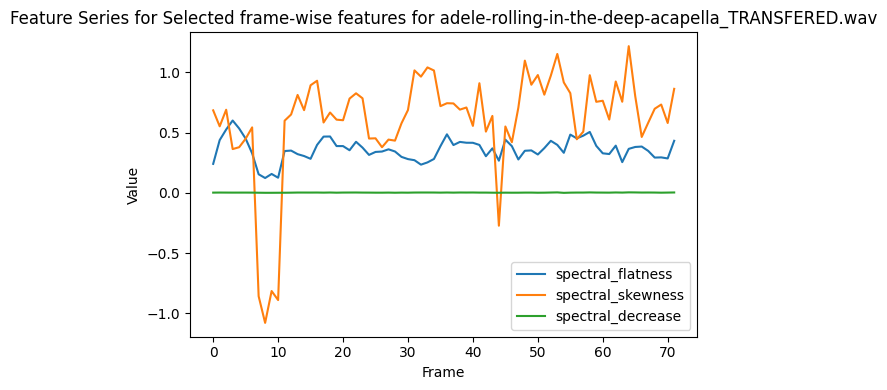

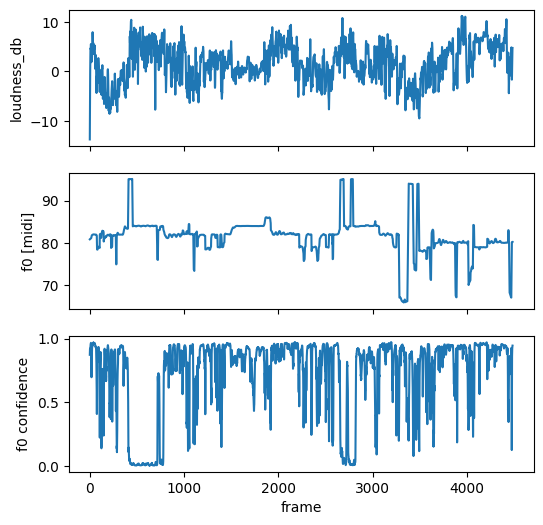

In [37]:
selected_metrics = [m for m in available if m in file_series.index]

if not selected_metrics:
    print("No selected metrics found in file_series.")
else:
    plot_series(
        file_series.loc[selected_metrics],
        name=f"Selected frame-wise features for {wav_path.name}",
    )
    plot_feature_from_audio(y_file)

In [38]:
from librosa import segment

from evaluation.segment import AudioSegmenter

segmenter = AudioSegmenter(sr = 16000)
segmenter.fit(y_file)
print(f"Estimated BPM: {segmenter.bpm:.2f}")


Estimated BPM: 156.25
